In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Colors
NAVY = '#1B3A6B'
RED = '#C62828'
GREEN = '#2E7D32'
ORANGE = '#E65100'
YELLOW = '#F9A825'

df = pd.read_csv('data/cleaned/loans_clean.csv', parse_dates=['disbursal_date'])

import os
os.makedirs('charts', exist_ok=True)

print("=== PORTFOLIO OVERVIEW ===")
print(f"Total Loans: {len(df):,}")
print(f"Portfolio Value: â‚¹{df['loan_amount'].sum()/1e7:.1f} Crore")
print(f"Default Rate: {df['is_defaulted'].mean()*100:.1f}%")
print(f"NPA Rate: {(df['loan_status']=='NPA').mean()*100:.1f}%")
print(f"Avg Credit Score: {df['credit_score'].mean():.0f}")
print(f"At-Risk Portfolio: â‚¹{df[df['is_defaulted']==1]['loan_amount'].sum()/1e7:.1f} Crore")






=== PORTFOLIO OVERVIEW ===
Total Loans: 9,908
Portfolio Value: â‚¹1288.1 Crore
Default Rate: 31.8%
NPA Rate: 9.5%
Avg Credit Score: 689
At-Risk Portfolio: â‚¹495.0 Crore


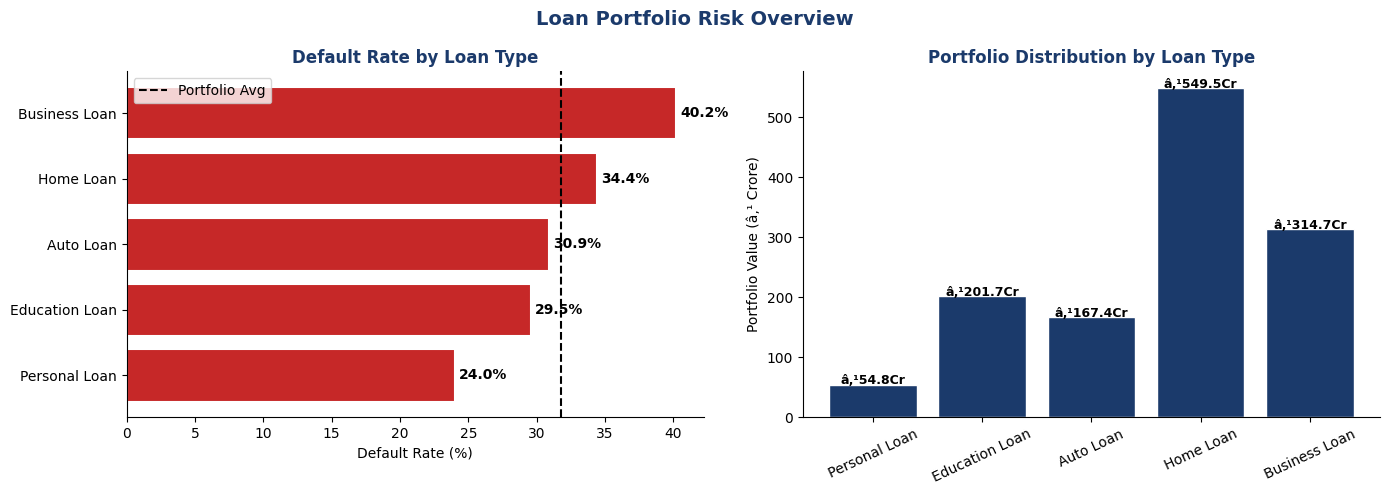

In [2]:
# **Chart 1 â€” Default Rate by Loan Type (Horizontal Bar)**


lt_analysis = df.groupby('loan_type').agg(
    default_rate=('is_defaulted', lambda x: x.mean()*100),
    portfolio_crore=('loan_amount', lambda x: x.sum()/1e7),
    loan_count=('loan_id', 'count')
).sort_values('default_rate', ascending=True).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = [RED if v > 20 else ORANGE if v > 15 else NAVY 
          for v in lt_analysis['default_rate']]
bars = ax1.barh(lt_analysis['loan_type'], lt_analysis['default_rate'], 
                color=colors, edgecolor='white', linewidth=1.5)
ax1.axvline(x=df['is_defaulted'].mean()*100, color='black', 
            linestyle='--', label='Portfolio Avg')
ax1.set_xlabel('Default Rate (%)')
ax1.set_title('Default Rate by Loan Type', fontweight='bold', color=NAVY)
for bar, val in zip(bars, lt_analysis['default_rate']):
    ax1.text(val+0.3, bar.get_y()+bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.bar(lt_analysis['loan_type'], lt_analysis['portfolio_crore'], 
        color=NAVY, edgecolor='white')
ax2.set_ylabel('Portfolio Value (â‚¹ Crore)')
ax2.set_title('Portfolio Distribution by Loan Type', fontweight='bold', color=NAVY)
ax2.tick_params(axis='x', rotation=25)
for i, val in enumerate(lt_analysis['portfolio_crore']):
    ax2.text(i, val+0.1, f'â‚¹{val:.1f}Cr', ha='center', fontsize=9, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Loan Portfolio Risk Overview', fontsize=14, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.savefig('charts/default_by_loantype.png', dpi=150, bbox_inches='tight')
plt.show()


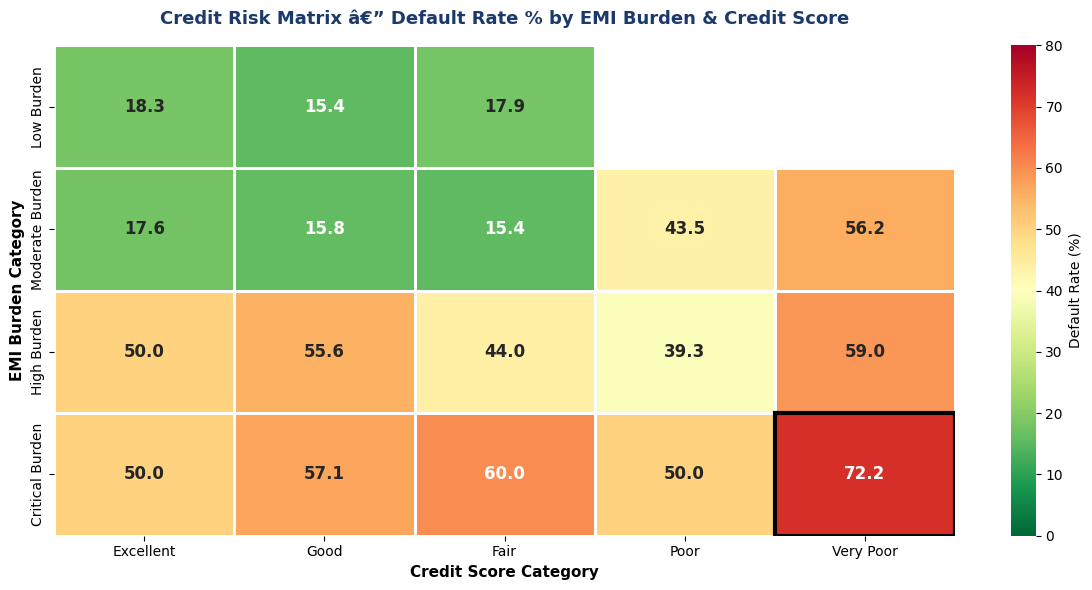

Highest Risk Combination Default Rate: 72.2%


In [3]:
# **Chart 2 â€” Risk Matrix Heatmap (EMI Burden Ã— Credit Category)**


# Risk matrix â€” recruiter ka favorite chart
burden_order = ['Low Burden', 'Moderate Burden', 'High Burden', 'Critical Burden']
credit_order = ['Excellent', 'Good', 'Fair', 'Poor', 'Very Poor']

risk_matrix = df.groupby(['emi_burden_category', 'credit_category'])['is_defaulted'].mean() * 100
risk_pivot = risk_matrix.unstack(fill_value=0)

# Reorder
risk_pivot = risk_pivot.reindex(
    index=[b for b in burden_order if b in risk_pivot.index],
    columns=[c for c in credit_order if c in risk_pivot.columns],
    fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 6))
mask = risk_pivot == 0
sns.heatmap(risk_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, linewidths=1, cbar_kws={'label': 'Default Rate (%)'},
            vmin=0, vmax=80, mask=mask, annot_kws={'size': 12, 'weight': 'bold'})

ax.set_title('Credit Risk Matrix â€” Default Rate % by EMI Burden & Credit Score',
             fontsize=13, fontweight='bold', color=NAVY, pad=15)
ax.set_xlabel('Credit Score Category', fontsize=11, fontweight='bold')
ax.set_ylabel('EMI Burden Category', fontsize=11, fontweight='bold')

# Highlight highest risk cell
ax.add_patch(plt.Rectangle((credit_order.index('Very Poor'), 
                              burden_order.index('Critical Burden')), 
                             1, 1, fill=False, edgecolor='black', lw=3))

plt.tight_layout()
plt.savefig('charts/risk_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight
worst = risk_pivot.max().max()
print(f"Highest Risk Combination Default Rate: {worst:.1f}%")


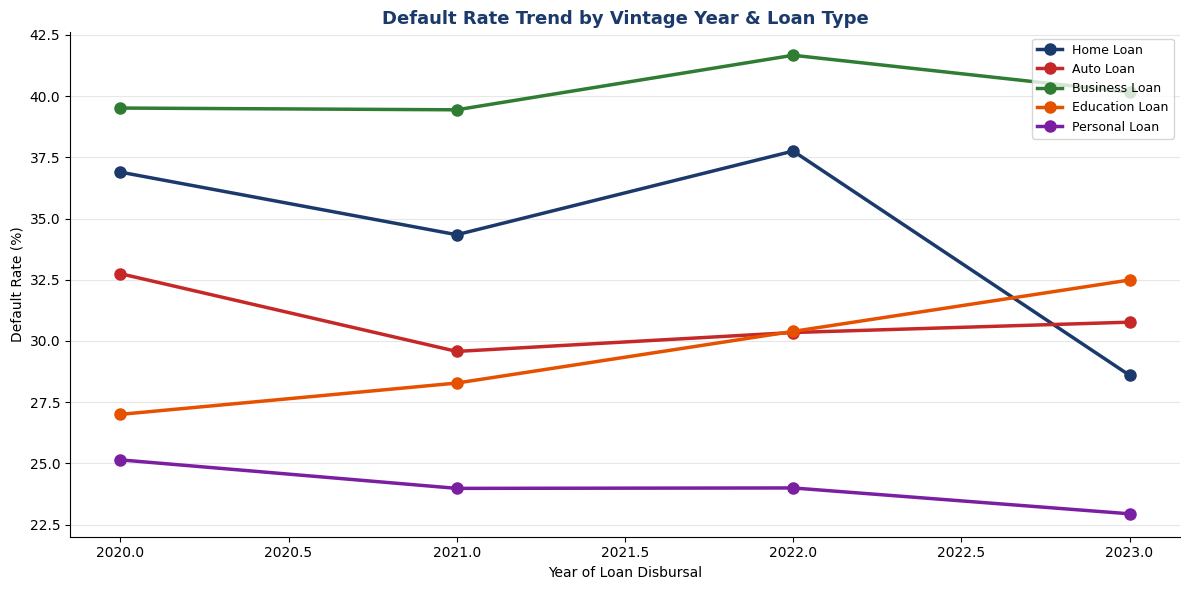

In [4]:
# **Chart 3 â€” Vintage Default Trend**


vintage = df.groupby(['disbursal_year', 'loan_type']).agg(
    default_rate=('is_defaulted', lambda x: x.mean()*100),
    loan_count=('loan_id', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
loan_types = df['loan_type'].unique()
colors_lt = [NAVY, RED, GREEN, ORANGE, '#7B1FA2']

for i, lt in enumerate(loan_types):
    data = vintage[vintage['loan_type'] == lt]
    ax.plot(data['disbursal_year'], data['default_rate'], 
            marker='o', linewidth=2.5, markersize=8,
            label=lt, color=colors_lt[i])

ax.set_title('Default Rate Trend by Vintage Year & Loan Type',
             fontsize=13, fontweight='bold', color=NAVY)
ax.set_xlabel('Year of Loan Disbursal')
ax.set_ylabel('Default Rate (%)')
ax.legend(loc='upper right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/vintage_trend.png', dpi=150, bbox_inches='tight')
plt.show()

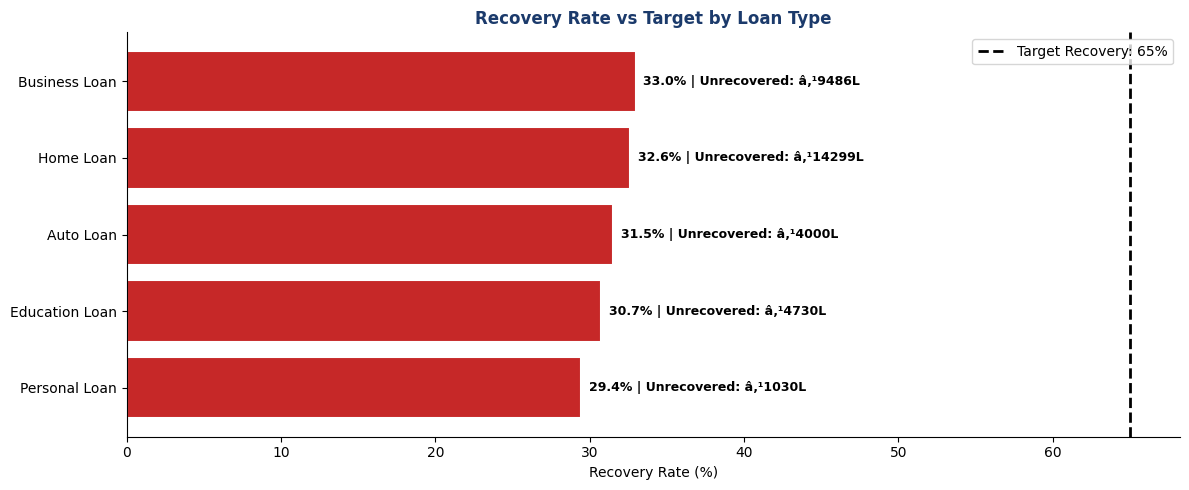

Total unrecovered amount below target: â‚¹335.4 Crore


In [5]:
# **Chart 4 â€” Recovery Rate Gap Analysis**


defaulted = df[df['is_defaulted'] == 1]

recovery = defaulted.groupby('loan_type').agg(
    defaulted_amount=('loan_amount', 'sum'),
    recovered_amount=('amount_recovered', 'sum')
).reset_index()

recovery['recovery_rate'] = recovery['recovered_amount'] / recovery['defaulted_amount'] * 100
recovery['gap'] = 100 - recovery['recovery_rate']
recovery['unrecovered'] = recovery['defaulted_amount'] - recovery['recovered_amount']
recovery = recovery.sort_values('recovery_rate')

TARGET_RECOVERY = 65  # Industry benchmark

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(recovery))
ax.barh(recovery['loan_type'], recovery['recovery_rate'], 
        color=[RED if r < TARGET_RECOVERY else GREEN for r in recovery['recovery_rate']],
        edgecolor='white', linewidth=1.5)
ax.axvline(x=TARGET_RECOVERY, color='black', linestyle='--', linewidth=2,
           label=f'Target Recovery: {TARGET_RECOVERY}%')

for i, (_, row) in enumerate(recovery.iterrows()):
    ax.text(row['recovery_rate']+0.5, i, 
            f"{row['recovery_rate']:.1f}% | Unrecovered: â‚¹{row['unrecovered']/1e5:.0f}L",
            va='center', fontsize=9, fontweight='bold')

ax.set_title('Recovery Rate vs Target by Loan Type', fontweight='bold', color=NAVY)
ax.set_xlabel('Recovery Rate (%)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('charts/recovery_gap.png', dpi=150, bbox_inches='tight')
plt.show()

below_target = recovery[recovery['recovery_rate'] < TARGET_RECOVERY]
total_gap = below_target['unrecovered'].sum()
print(f"Total unrecovered amount below target: â‚¹{total_gap/1e7:.1f} Crore")


In [6]:
# **Impact Numbers Print Karo:**


print("\n" + "="*55)
print("BUSINESS IMPACT SUMMARY â€” RESUME MEIN YAHI LIKHNA")
print("="*55)

portfolio = df['loan_amount'].sum()
defaulted_amt = df[df['is_defaulted']==1]['loan_amount'].sum()
at_risk_pct = defaulted_amt / portfolio * 100

npa_count = (df['loan_status']=='NPA').sum()
npa_pct = npa_count / len(df) * 100

high_risk = df[df['emi_to_income_ratio'] > 40]
high_risk_pct = len(high_risk) / len(df) * 100

recovered = df['amount_recovered'].sum()
recovery_rate = recovered / defaulted_amt * 100

print(f"Total Loans Analyzed: {len(df):,}")
print(f"Portfolio Value: â‚¹{portfolio/1e7:.1f} Crore")
print(f"Default Rate: {df['is_defaulted'].mean()*100:.1f}%")
print(f"At-Risk Portfolio: â‚¹{defaulted_amt/1e7:.1f} Crore ({at_risk_pct:.1f}%)")
print(f"NPA Rate: {npa_pct:.1f}%")
print(f"High EMI Burden (>40%): {high_risk_pct:.1f}% of borrowers")
print(f"Overall Recovery Rate: {recovery_rate:.1f}%")
print(f"Recovery Gap from 65% target: {65-recovery_rate:.1f} percentage points")
print(f"Unrecovered Amount: â‚¹{(defaulted_amt-recovered)/1e7:.1f} Crore")


BUSINESS IMPACT SUMMARY â€” RESUME MEIN YAHI LIKHNA
Total Loans Analyzed: 9,908
Portfolio Value: â‚¹1288.1 Crore
Default Rate: 31.8%
At-Risk Portfolio: â‚¹495.0 Crore (38.4%)
NPA Rate: 9.5%
High EMI Burden (>40%): 27.5% of borrowers
Overall Recovery Rate: 32.2%
Recovery Gap from 65% target: 32.8 percentage points
Unrecovered Amount: â‚¹335.4 Crore
